<a href="https://colab.research.google.com/github/abegyaberhanu/Abby-s_Portfolio/blob/main/Fraud_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Fraud Detection**
* Linear Regression Model

##Importing Libraries

In [15]:
# import all the libraries of code from python to reduce size of file and increase efficiency
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import specific funtions from differnt libraries so we don't have to import whole
# libraries to reduce computational power needed
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import calendar
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, accuracy_score, mean_squared_error, root_mean_squared_error, confusion_matrix, recall_score


#Import file and read the CSV file into a pandas DataFrame
data = '/content/drive/MyDrive/fraud_oracle.csv'
df = pd.read_csv(data)


##Preprocessing Data

###Data Check

In [16]:
#Check the data type of each row and if null values are present
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [17]:
# Print unique values for non-numericals columns to inspect their content
for col in df.columns:
  if df[col].dtype == 'object':
      print(f"Unique values for column '{col}':")
      print(df[col].unique())
      print("\n")

Unique values for column 'Month':
['Dec' 'Jan' 'Oct' 'Jun' 'Feb' 'Nov' 'Apr' 'Mar' 'Aug' 'Jul' 'May' 'Sep']


Unique values for column 'DayOfWeek':
['Wednesday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']


Unique values for column 'Make':
['Honda' 'Toyota' 'Ford' 'Mazda' 'Chevrolet' 'Pontiac' 'Accura' 'Dodge'
 'Mercury' 'Jaguar' 'Nisson' 'VW' 'Saab' 'Saturn' 'Porche' 'BMW' 'Mecedes'
 'Ferrari' 'Lexus']


Unique values for column 'AccidentArea':
['Urban' 'Rural']


Unique values for column 'DayOfWeekClaimed':
['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday'
 '0']


Unique values for column 'MonthClaimed':
['Jan' 'Nov' 'Jul' 'Feb' 'Mar' 'Dec' 'Apr' 'Aug' 'May' 'Jun' 'Sep' 'Oct'
 '0']


Unique values for column 'Sex':
['Female' 'Male']


Unique values for column 'MaritalStatus':
['Single' 'Married' 'Widow' 'Divorced']


Unique values for column 'Fault':
['Policy Holder' 'Third Party']


Unique values for column 'PolicyType':
['Sport - Liability' 'Sp

###Encoding

In [18]:
#Manually encode the variables with minimal unique values
df["PoliceReportFiled"] = [1 if val == "Yes" else 0 for val in df["PoliceReportFiled"]]
df["WitnessPresent"] = [1 if val == "Yes" else 0 for val in df["WitnessPresent"]]
df["Sex"] = [1 if val == "Male" else 0 for val in df["Sex"]]
df["AccidentArea"] = [1 if val == "Urban" else 0 for val in df["AccidentArea"] ]
df["Fault"] = [1 if val == "Policy Holder" else 0 for val in df["Fault"]]
df["AgentType"] = [1 if val == "External" else 0 for val in df ["AgentType"]]

#use python library to encode calendar related values
day_mapping = {name: i for i, name in enumerate(calendar.day_name)}
day_mapping["0"] = 0
month_mapping = {name: num for num, name in enumerate(calendar.month_abbr) if num}
month_mapping ["0"] = 0

# Use the .replace() method to create a new column with numerical values
df['DayOfWeek'] = df['DayOfWeek'].replace(day_mapping)
df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].replace(day_mapping)

df['Month'] = df["Month"].replace(month_mapping)
df['MonthClaimed'] = df['MonthClaimed'].replace(month_mapping)

#Encode the only non-numerical value in the variables
df.loc[df["PastNumberOfClaims"] == "none", "PastNumberOfClaims"] = 0
df.loc[df["NumberOfSuppliments"] == "none", "NumberOfSuppliments"] = 0

#encode the rest of the variables with numerical values
data_dummies = pd.get_dummies(df).astype("int64")
(data_dummies.dtypes == "Object").any()

#Display to ensure correct encoding
print(data_dummies)

       Month  WeekOfMonth  DayOfWeek  AccidentArea  DayOfWeekClaimed  \
0         12            5          2             1                 1   
1          1            3          2             1                 0   
2         10            5          4             1                 3   
3          6            2          5             0                 4   
4          1            5          0             1                 1   
...      ...          ...        ...           ...               ...   
15415     11            4          4             1                 1   
15416     11            5          3             1                 4   
15417     11            5          3             0                 4   
15418     12            1          0             1                 3   
15419     12            2          2             1                 3   

       MonthClaimed  WeekOfMonthClaimed  Sex  Age  Fault  ...  \
0                 1                   1    0   21      1  ...   
1    

/tmp/ipykernel_441/907602723.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['DayOfWeek'] = df['DayOfWeek'].replace(day_mapping)
/tmp/ipykernel_441/907602723.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['DayOfWeekClaimed'] = df['DayOfWeekClaimed'].replace(day_mapping)
/tmp/ipykernel_441/907602723.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future beha

##Model Building

####Initial Model
* No variable engineering
* No value balancing

In [19]:
#Split the data into traning and testing data

x = data_dummies.drop(['FraudFound_P'], axis=1)
y = data_dummies.filter(["FraudFound_P"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= .2, random_state = 42, stratify=y)

#Initiate and train the data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

#Compare the accuracy
y_predict = regressor.predict(X_test)


#### Feature Engineering
* Identify Correlation and feature selection

In [20]:
#Identify the correlations of variables to fraud and identify the top features

correlation_matrix = data_dummies.corr()
target_correlations = correlation_matrix["FraudFound_P"]
target_correlations = target_correlations.loc[target_correlations.index != "FraudFound_P"]

#Sort the values in descending order
highest_correlated_vars = target_correlations.sort_values(ascending=False)

#Set a correlation threshdold and filter to select highly correclated features
high_correlation_threshold = 0.1
highly_correlated_features = highest_correlated_vars[abs(highest_correlated_vars) > high_correlation_threshold]
print("\nVariables with absolute correlation above",  high_correlation_threshold)
print(highly_correlated_features)



Variables with absolute correlation above 0.1
Fault                            0.131389
VehicleCategory_Sedan            0.122182
BasePolicy_All Perils            0.112044
PolicyType_Sedan - All Perils    0.103045
VehicleCategory_Sport           -0.135903
PolicyType_Sedan - Liability    -0.153413
BasePolicy_Liability            -0.154007
Name: FraudFound_P, dtype: float64


In [21]:
#Select the identified top features and populate the x and y variables with them
columns_to_keep = ['Fault', "VehicleCategory_Sedan", "BasePolicy_All Perils", "PolicyType_Sedan - All Perils", "VehicleCategory_Sport",
                   "PolicyType_Sedan - Liability", "BasePolicy_Liability"]
x = data_dummies.filter(columns_to_keep, axis=1)
y = data_dummies.filter(["FraudFound_P"], axis=1)
print(x)


       Fault  VehicleCategory_Sedan  BasePolicy_All Perils  \
0          1                      0                      0   
1          1                      0                      0   
2          1                      0                      0   
3          0                      0                      0   
4          0                      0                      0   
...      ...                    ...                    ...   
15415      1                      1                      0   
15416      1                      0                      0   
15417      1                      1                      0   
15418      0                      1                      1   
15419      1                      1                      0   

       PolicyType_Sedan - All Perils  VehicleCategory_Sport  \
0                                  0                      1   
1                                  0                      1   
2                                  0                      1   
3  

####Iteration #1
* Address representation imbalance
* Feature Engineering


In [22]:
#address representation imbalance using the SMOTE function

smote = SMOTE()
x_res, y_res = smote.fit_resample(x, y)

# Combine x_res and y_res into oversampled_data using concat
oversampled_data = pd.concat([x_res, y_res], axis=1)


x = oversampled_data.drop(["FraudFound_P"], axis=1)
y = oversampled_data.filter(["FraudFound_P"], axis=1)
x = np.array(x)
y = np.array(y)

#Split the data into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= .2, random_state = 42)

#Initiate and train the model with the selected features
regressor = LinearRegression()
regressor.fit(X_train, y_train)

#test the accuracy of the model aganist the known values
y_predict = regressor.predict(X_test)
metrics.r2_score(y_test, y_predict)


0.27452583760921256

####Iteration #2
* All Features
* Final Iteration

In [23]:
#Reinitialize and populate x and y with all the variables
x = data_dummies.drop("FraudFound_P", axis=1)
y = data_dummies.filter(["FraudFound_P"], axis=1)

#Address representation imbalance and build the model again with all the variables

#Address imbalance
smote = SMOTE()
x_res, y_res = smote.fit_resample(x, y)

# Combine x_res and y_res into oversampled_data using concat
oversampled_data = pd.concat([x_res, y_res], axis=1)



x = oversampled_data.drop(["FraudFound_P"], axis=1)
y = oversampled_data.filter(["FraudFound_P"], axis=1)
x = np.array(x)
y = np.array(y)

#Split the data into training and testing data and train the model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= .3, random_state = 0)
regressor = LinearRegression()
regressor.fit(X_train, y_train)

#test the accuracy of the new model aganist the known values
y_predict = regressor.predict(X_test)

#Model Evaluation metrics
R_squared = metrics.r2_score(y_test, y_predict)
y_predict_binary = (y_predict >= 0.5).astype(int)

#test the accuracy of the model
score = accuracy_score(y_test, y_predict_binary)
print ("R squared =", R_squared)
print("Accuracy score = ", score)
print("Mean Squared error = ", mean_squared_error(y_test, y_predict_binary))
print("Root mean squared error = ", root_mean_squared_error(y_test, y_predict))
print("Confusion metrix : \n", confusion_matrix(y_test, y_predict_binary))
print("Recall = ", recall_score(y_test, y_predict_binary) )


R squared = 0.8277369005780552
Accuracy score =  0.9650534544200483
Mean Squared error =  0.03494654557995172
Root mean squared error =  0.20752271845866627
Confusion metrix : 
 [[4342    1]
 [ 303 4053]]
Recall =  0.9304407713498623


## Result Visualization

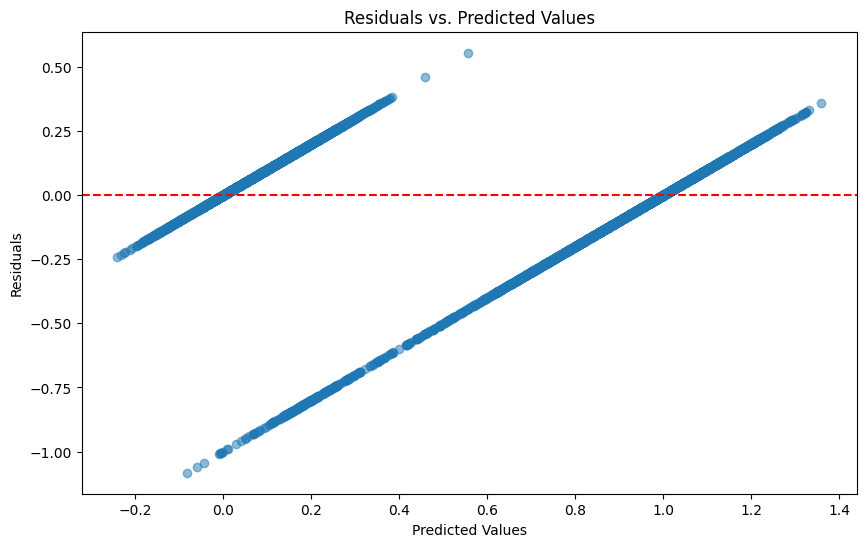

In [24]:
residuals = y_predict - y_test
plt.figure(figsize=(10, 6))
plt.scatter(y_predict, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted Values")
plt.show()

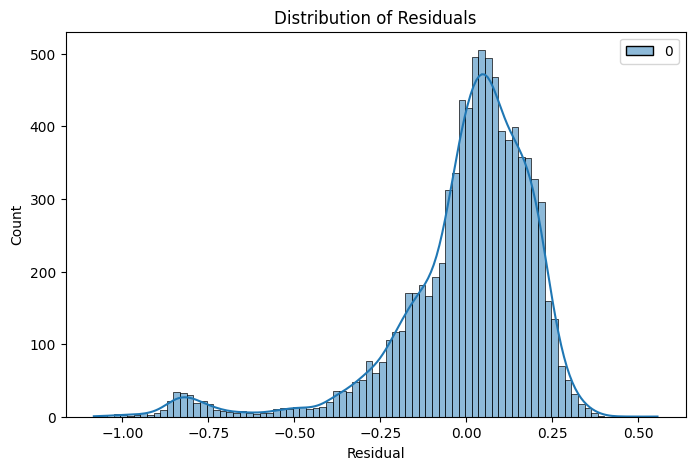

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()